In [55]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from scipy.signal import detrend
from scipy.linalg import svd
from scipy.fft import fft, fftfreq

In [56]:
def calibration(data, bias, matrix=None):
    if matrix is None:
        return data - bias
    calibrated_data = np.dot(matrix, (data - bias).T).T 
    return calibrated_data

raw_df = pd.read_csv('center_sternum.txt', delimiter='\t')
raw_df

,Log Mode,Log Freq,Timestamp,AccX,AccY,AccZ,GyroX,GyroY,GyroZ,MagnX,MagnY,MagnZ,qw,qi,qj,qk
0,5,200,1576222772,947.086,435.662,70.638,-6.824428,-14.244280,1.404580,-454,-490,-178,0.792622,0.254952,-0.553850,-0.000031
1,5,200,1576222772,969.168,387.777,88.877,6.183206,-12.290080,-7.969466,-454,-490,-177,0.736461,0.275124,-0.617969,0.006806
2,5,200,1576222772,989.603,380.335,78.751,11.709920,-4.961832,-7.450382,-454,-490,-177,0.729465,0.275246,-0.626118,0.009827
3,5,200,1576222772,954.894,418.033,88.328,17.877860,2.519084,-5.984733,-454,-492,-176,0.723413,0.277200,-0.632221,0.011383
4,5,200,1576222772,972.096,427.732,99.857,25.221370,5.404580,4.015267,-454,-492,-176,0.721948,0.280007,-0.632679,0.010193
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
16501,5,200,1576222847,958.493,291.092,-54.290,1.664122,2.305344,-0.671756,-494,-449,-126,0.650810,0.379162,-0.636402,0.166356
16502,5,200,1576222847,954.650,288.042,-49.654,1.480916,2.488550,-0.702290,-494,-450,-125,0.650239,0.379803,-0.636708,0.165960
16503,5,200,1576222847,967.338,290.482,-63.867,1.114504,3.374046,-0.900763,-494,-450,-125,0.649365,0.380627,-0.637227,0.165502
16504,5,200,1576222847,965.630,300.852,-56.242,0.702290,3.664122,-1.587786,-495,-448,-124,0.648973,0.381329,-0.637348,0.164953


In [57]:
offset_gyro = np.array([-2.242224, 2.963463, -0.718397])

calibration_acc = np.array([[1.000966,     -0.002326418,-0.0006995499],
                            [-0.002326379,  0.9787045,  -0.001540918],
                            [-0.0006995811,-0.001540928, 1.00403]])
offset_acc = np.array([-3.929942, -13.74679, 60.67546])

calibration_magn = np.array([[0.9192851, -0.02325168, 0.003480837],
                             [-0.02325175, 0.914876, 0.004257396],
                             [0.003481006, 0.004257583, 0.8748001]])

offset_magn = np.array([-95.67974, -244.9142, 17.71132])

Data taking lasted: 82.525 seconds


,Time,AccX,AccY,AccZ,GyroX,GyroY,GyroZ,MagnX,MagnY,MagnZ
0,0.000,942.993735,410.533833,130.532698,-9.066652,-11.280817,0.686183,-488.782344,-660.256760,-145.262950
1,0.005,965.195708,363.589092,148.903540,3.940982,-9.326617,-8.687863,-488.778863,-660.252503,-144.388150
2,0.010,985.674845,356.273637,138.733904,9.467696,-1.998369,-8.168779,-488.778863,-660.252503,-144.388150
3,0.015,950.837915,393.234828,148.315692,15.635636,5.482547,-6.703130,-488.728879,-662.077997,-143.521865
4,0.020,968.025903,402.669499,159.864174,22.979146,8.368043,3.296870,-488.728879,-662.077997,-143.521865
...,...,...,...,...,...,...,...,...,...,...
16501,82.505,954.835478,269.208490,5.316030,-0.578102,5.268807,-1.390153,-526.326063,-621.595390,-99.738024
16502,82.510,950.992618,266.225238,9.978102,-0.761308,5.452013,-1.420687,-526.299331,-622.506008,-98.867482
16503,82.515,963.697141,268.605661,-4.304813,-1.127720,6.337509,-1.619160,-526.299331,-622.506008,-98.867482
16504,82.520,961.958032,278.747051,3.336131,-1.539934,6.627585,-2.306183,-527.261638,-620.648747,-97.987647


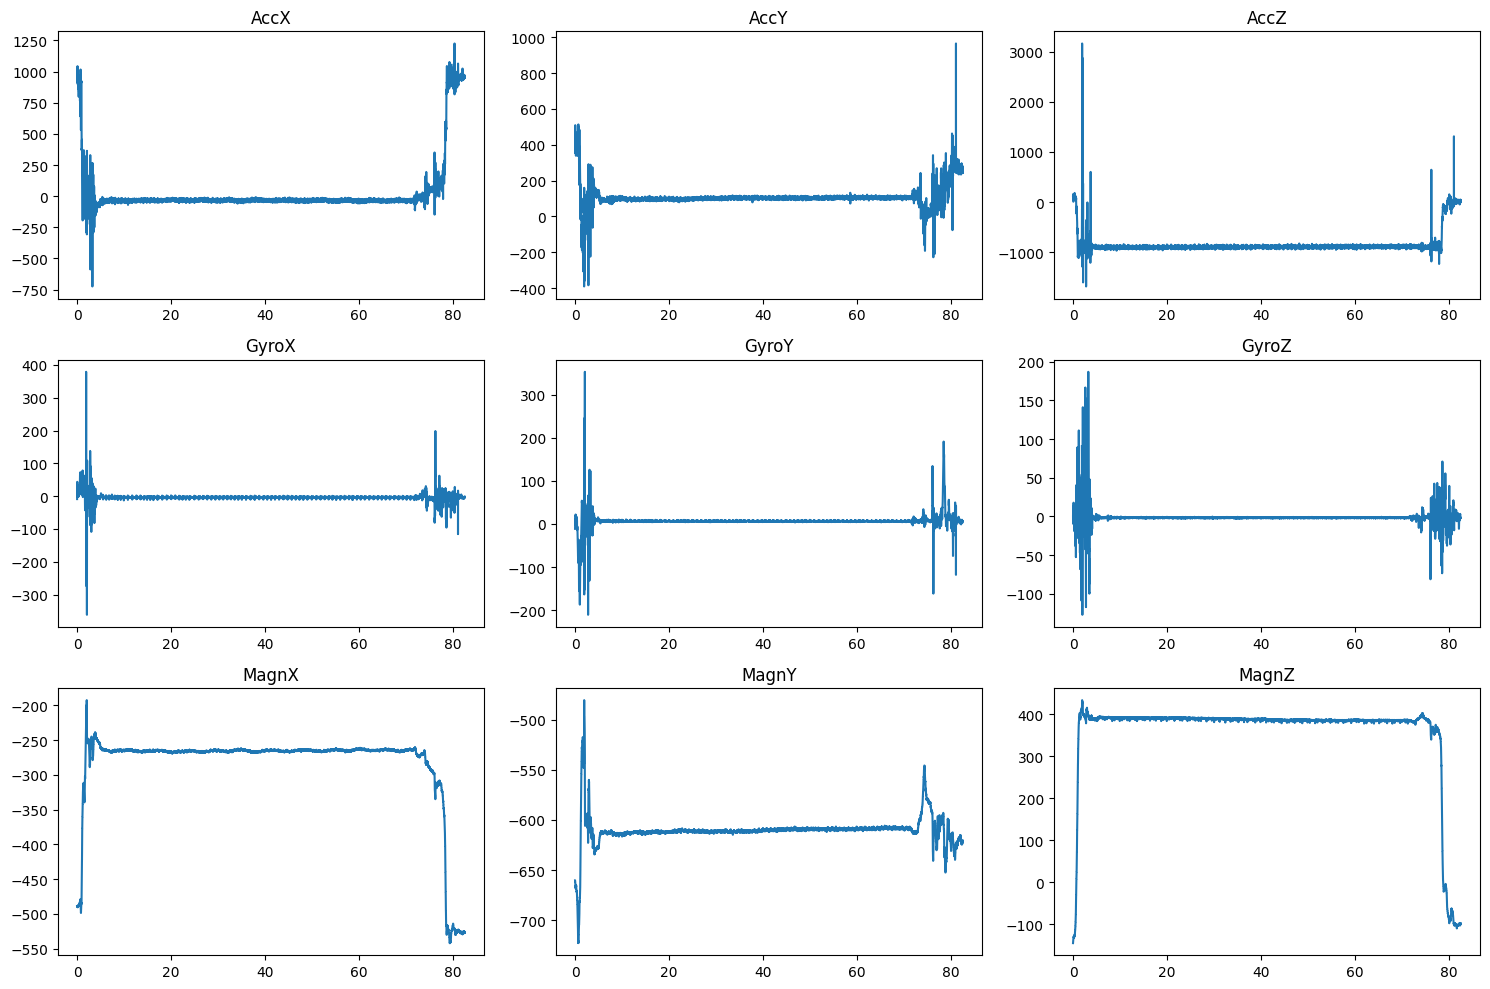

In [58]:
LOG_FREQ = raw_df['Log Freq'][0]

raw_df = raw_df.drop(columns=['Log Freq', 'Log Mode', 'Timestamp', 'qw', 'qi', 'qj', 'qk'])

time = np.arange(raw_df.shape[0])/LOG_FREQ
print(f'Data taking lasted: {time[-1]} seconds')

raw_df.insert(0, 'Time', time)

raw_df[['AccX', 'AccY', 'AccZ']] = np.dot(raw_df[['AccX', 'AccY', 'AccZ']] + offset_acc.T, calibration_acc.T)
raw_df[['GyroX', 'GyroY', 'GyroZ']] = raw_df[['GyroX', 'GyroY', 'GyroZ']] + offset_gyro.T
raw_df[['MagnX', 'MagnY', 'MagnZ']] = np.dot(raw_df[['MagnX', 'MagnY', 'MagnZ']] + offset_magn.T, calibration_magn.T)

display(raw_df)

fig, axs = plt.subplots(3, 3, figsize=(15, 10))
for i, col in enumerate(raw_df.columns[1:]):
    axs[i//3, i%3].plot(raw_df['Time'], raw_df[col])
    axs[i//3, i%3].set_title(col)
plt.tight_layout()
plt.show()

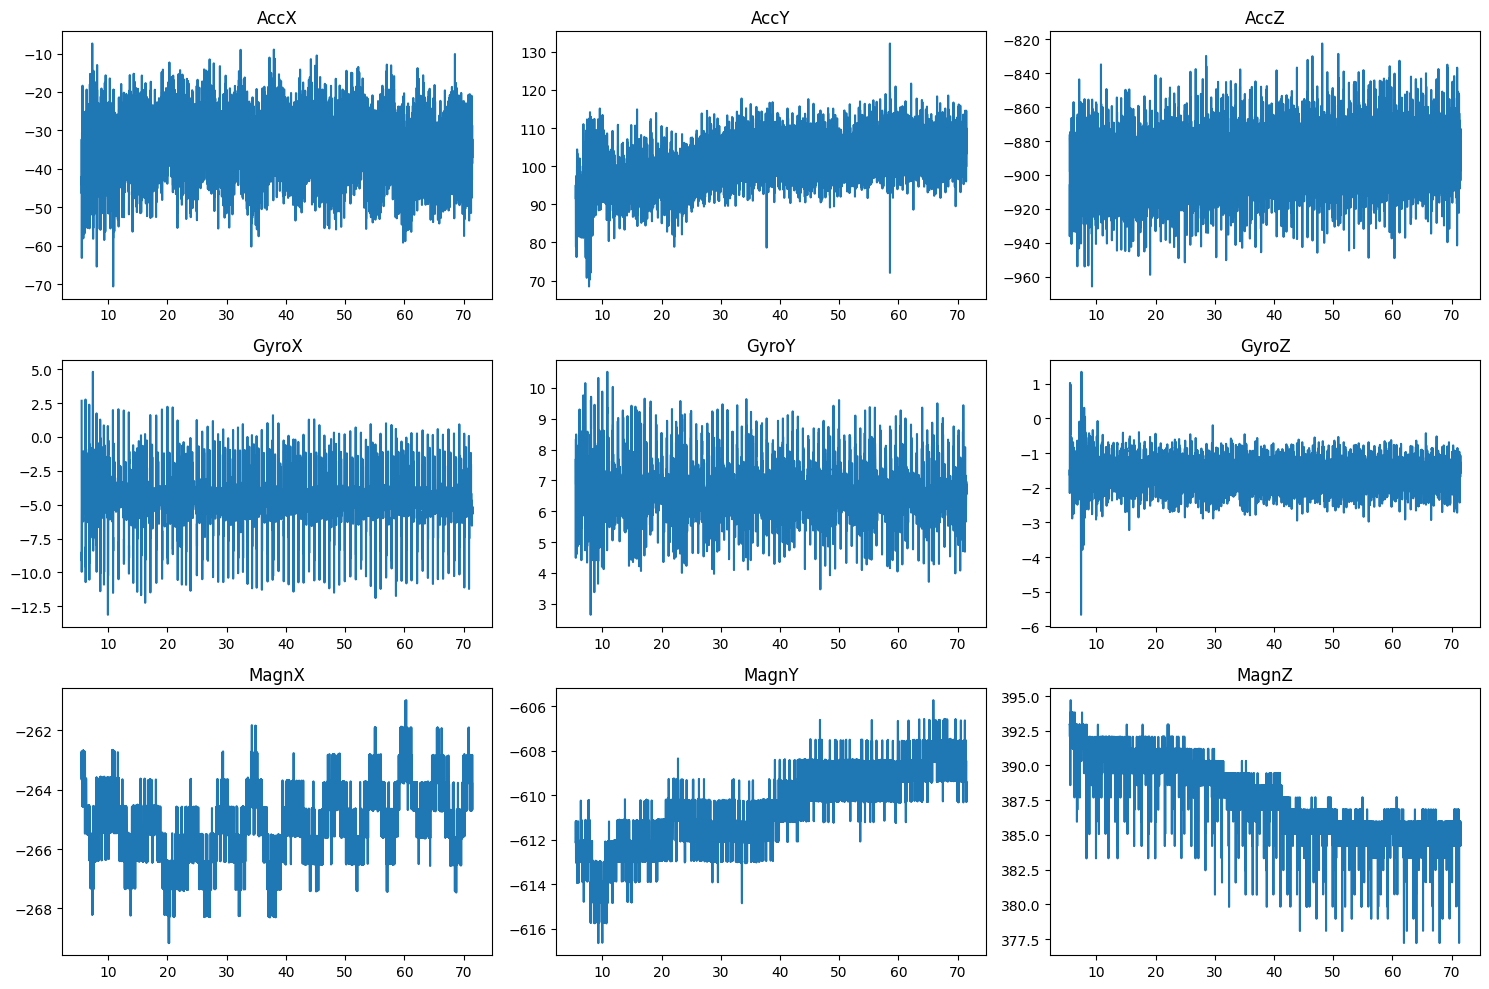

In [59]:
df = raw_df[(raw_df['Time'] > 5.5) & (raw_df['Time'] < 71.5)]

fig, axs = plt.subplots(3, 3, figsize=(15, 10))
for i, col in enumerate(df.columns[1:]):
    axs[i//3, i%3].plot(df['Time'], df[col])
    axs[i//3, i%3].set_title(col)
plt.tight_layout()
plt.show()

/tmp/ipykernel_11319/1441352835.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df[col] = detrend(df[col])


,Time,AccX,AccY,AccZ,GyroX,GyroY,GyroZ,MagnX,MagnY,MagnZ
1101,5.505,-10.304781,-3.710784,-6.423061,6.917568,0.931636,-0.064890,3.156265,1.149839,1.176199
1102,5.510,-10.472448,-1.336786,-36.438138,3.085520,0.259893,0.072518,2.213617,2.087561,1.177596
1103,5.515,-10.172971,-2.731745,-23.208172,-3.799963,-0.060705,-0.599234,2.213506,2.087156,1.178217
1104,5.520,1.285218,-0.284987,-1.601447,-5.708347,-0.793518,-0.217550,3.132680,2.063499,1.182318
1105,5.525,-12.829332,-3.395925,23.461761,-5.036577,-2.243886,0.484744,3.132569,2.063094,1.182938
...,...,...,...,...,...,...,...,...,...,...
14295,71.475,3.099261,0.369090,-13.138315,-0.709255,0.391251,0.322972,0.697991,-2.377166,2.367376
14296,71.480,-1.800346,-0.913768,12.711731,-0.892447,0.253858,0.536716,0.697880,-2.377571,2.367997
14297,71.485,1.093308,-1.889180,-17.912674,-0.846633,0.101199,0.261911,0.667556,-1.471615,0.623274
14298,71.490,-0.070843,-4.176999,-4.190307,-1.274101,0.376020,0.032907,0.667445,-1.472020,0.623895


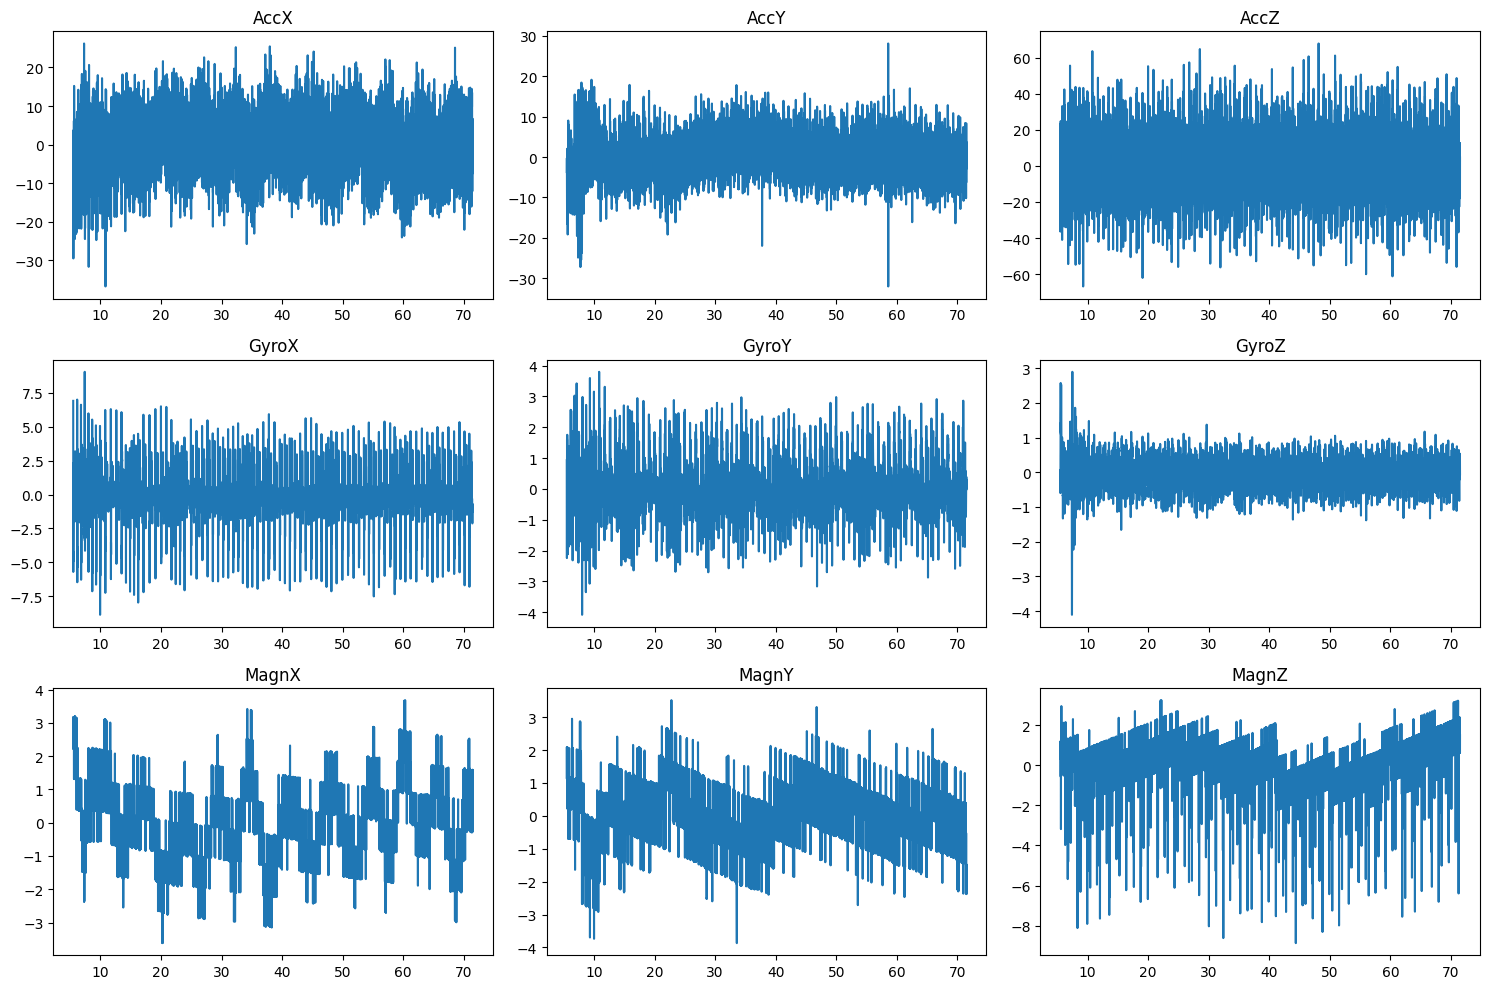

In [60]:
# apply detrend to each entry of the dataframe

for col in df.columns[1:]:
    df[col] = detrend(df[col])

display(df)

# plot
fig, axs = plt.subplots(3, 3, figsize=(15, 10))
for i, col in enumerate(df.columns[1:]):
    axs[i//3, i%3].plot(df['Time'], df[col])
    axs[i//3, i%3].set_title(col)
plt.tight_layout()
plt.show()

In [ ]:
def apply_pca(df, columns):
    '''
    Apply PCA to the given dataframe and columns using SVD.
    
    Parameters:
    df: the input dataframe
    columns: the columns to apply PCA to
    
    Returns:
    projected_data: data projection on the principal components
    variability: the variability of each principal component (descending order)
    principal_axes: the principal components ordered by variability (descending order)
    '''
    
    X = df[columns].to_numpy()
    N = X.shape[0]

    X_centered = X - np.mean(X, axis=0) # we center the data also if we have already done detrending, to be sure that the mean is zero

    U, sigma, Vt = svd(X_centered)
    
    eigenvalues = (sigma**2) / (N - 1)
    cov_trace = np.sum(eigenvalues)
    variability = eigenvalues / cov_trace
    
    pc = Vt.T 
    
    projected_data = np.dot(X_centered, pc)
    
    return projected_data, variability, pc

low_cut = 0.08 # Hz 
high_cut = 0.8

Variability of each PC: [0.76826453 0.15386232 0.07787315]
Respiratory Peak: 0.20 Hz (11.8 breaths/min)


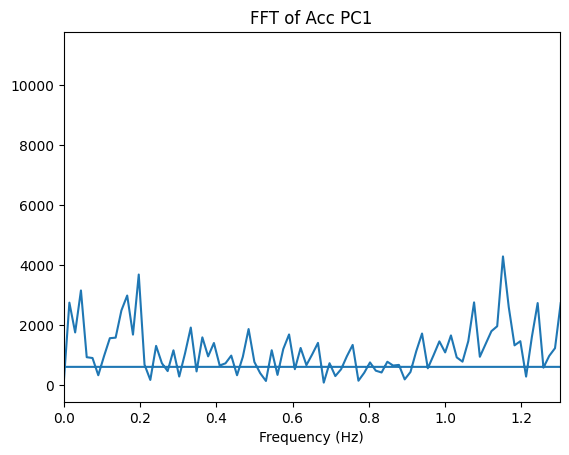

In [66]:
acc, variability_acc, pc_acc = apply_pca(df, ['AccX', 'AccY', 'AccZ'])
print(f'Variability of each PC: {variability_acc}')

acc1 = acc[:, 0]
acc_fft = fft(acc1)
freq_acc = fftfreq(len(acc1), d=1/200)

respiratory_mask = (freq_acc >= low_cut) & (freq_acc <= high_cut)

freqs_in_range = freq_acc[respiratory_mask]
peak_freq_resp = freqs_in_range[np.argmax(np.abs(acc_fft[respiratory_mask]))]
print(f'Respiratory Peak: {peak_freq_resp:.2f} Hz ({peak_freq_resp * 60:.1f} breaths/min)')

plt.plot(freq_acc, np.abs(acc_fft))
plt.xlim(0, high_cut+0.5)
plt.title('FFT of Acc PC1')
plt.xlabel('Frequency (Hz)')
plt.show()

Variability of each PC: [0.79714689 0.1592931  0.04356001]
Respiratory Peak: 0.21 Hz (12.7 breaths/min)


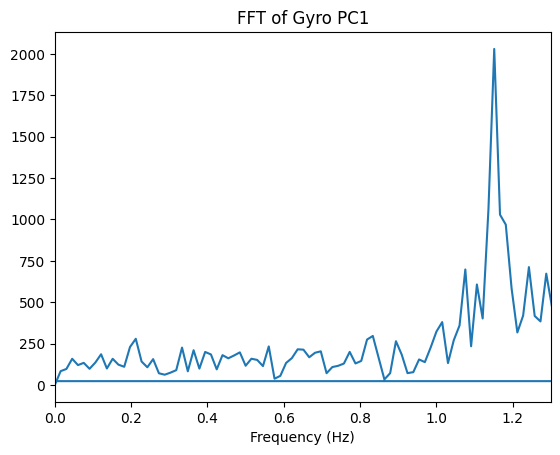

In [ ]:
gyro, variability_gyro, pc_gyro = apply_pca(df, ['GyroX', 'GyroY', 'GyroZ'])
print(f'Variability of each PC: {variability_gyro}')

gyro1 = gyro[:, 0]
gyro_fft = fft(gyro1)
freq_gyro = fftfreq(len(gyro1), d=1/200)

respiratory_mask_gyro = (freq_gyro >= low_cut) & (freq_gyro <= high_cut)

freqs_in_range_gyro = freq_gyro[respiratory_mask_gyro]
peak_freq_resp_gyro = freqs_in_range_gyro[np.argmax(np.abs(gyro_fft[respiratory_mask_gyro]))]
print(f'Respiratory Peak: {peak_freq_resp_gyro:.2f} Hz ({peak_freq_resp_gyro * 60:.1f} breaths/min)')

plt.plot(freq_gyro, np.abs(gyro_fft))
plt.xlim(0, high_cut+0.5)
plt.title('FFT of Gyro PC1')
plt.xlabel('Frequency (Hz)')
plt.show()

Variability of each PC: [0.4307577  0.35985239 0.20938991]
Respiratory Peak: 0.17 Hz (10.0 breaths/min)


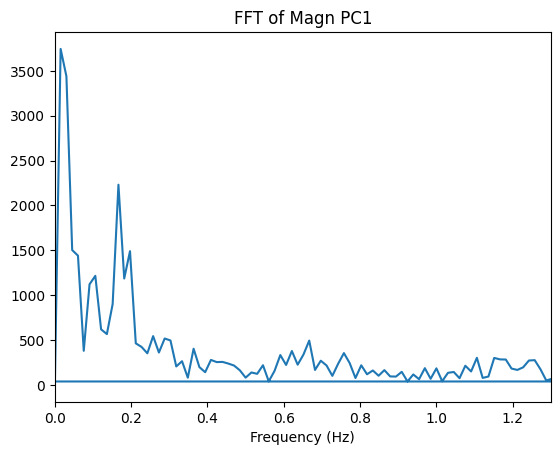

In [ ]:
magn, variability_magn, pc_magn = apply_pca(df, ['MagnX', 'MagnY', 'MagnZ'])
print(f'Variability of each PC: {variability_magn}')

magn1 = magn[:, 0]
magn_fft = fft(magn1)
freq_magn = fftfreq(len(magn1), d=1/200)

respiratory_mask_magn = (freq_magn >= low_cut) & (freq_magn <= high_cut)

freqs_in_range_magn = freq_magn[respiratory_mask_magn]
peak_freq_resp_magn = freqs_in_range_magn[np.argmax(np.abs(magn_fft[respiratory_mask_magn]))]
print(f'Respiratory Peak: {peak_freq_resp_magn:.2f} Hz ({peak_freq_resp_magn * 60:.1f} breaths/min)')

plt.plot(freq_magn, np.abs(magn_fft))
plt.xlim(0, high_cut+0.5)
plt.title('FFT of Magn PC1')
plt.xlabel('Frequency (Hz)')
plt.show()